In [42]:
import pandas as pd

all_years = pd.read_csv('./data/site_species_presence.csv')
combined = pd.read_csv('./data/site_species_presence_combined.csv')

# all_years = all_years[['Unique_ID', 'latitude', 'longitude', 'watershed_area', 'cw_ind', 'pct_dev']]
# combined = combined[['Unique_ID', 'latitude', 'longitude', 'watershed_area', 'cw_ind', 'pct_dev']]

In [43]:
all_3 = all_years[all_years['pct_dev'] <= 3]
all_5 = all_years[all_years['pct_dev'] <= 5]
all_7 = all_years[all_years['pct_dev'] <= 7]
all_10 = all_years[all_years['pct_dev'] <= 10]
all_15 = all_years[all_years['pct_dev'] <= 15]

print("All Years Dataset: 3% development threshold")
print(all_3['cw_ind'].value_counts())
print("\nAll Years Dataset: 5% development threshold")
print(all_5['cw_ind'].value_counts())
print("\nAll Years Dataset: 7% development threshold")
print(all_7['cw_ind'].value_counts())
print("\nAll Years Dataset: 10% development threshold")
print(all_10['cw_ind'].value_counts())
print("\nAll Years Dataset: 15% development threshold")
print(all_15['cw_ind'].value_counts())

All Years Dataset: 3% development threshold
cw_ind
1    201
0     33
Name: count, dtype: int64

All Years Dataset: 5% development threshold
cw_ind
1    271
0     75
Name: count, dtype: int64

All Years Dataset: 7% development threshold
cw_ind
1    309
0    110
Name: count, dtype: int64

All Years Dataset: 10% development threshold
cw_ind
1    327
0    135
Name: count, dtype: int64

All Years Dataset: 15% development threshold
cw_ind
1    339
0    169
Name: count, dtype: int64


In [44]:
comb_3 = combined[combined['pct_dev'] <= 3]
comb_5 = combined[combined['pct_dev'] <= 5]
comb_7 = combined[combined['pct_dev'] <= 7]
comb_10 = combined[combined['pct_dev'] <= 10]
comb_15 = combined[combined['pct_dev'] <= 15]

print("Combined Dataset: 3% development threshold")
print(comb_3['cw_ind'].value_counts())
print("\nCombined Dataset: 5% development threshold")
print(comb_5['cw_ind'].value_counts())
print("\nCombined Dataset: 7% development threshold")
print(comb_7['cw_ind'].value_counts())
print("\nCombined Dataset: 10% development threshold")
print(comb_10['cw_ind'].value_counts())
print("\nCombined Dataset: 15% development threshold")
print(comb_15['cw_ind'].value_counts())

Combined Dataset: 3% development threshold
cw_ind
1    170
0     27
Name: count, dtype: int64

Combined Dataset: 5% development threshold
cw_ind
1    227
0     60
Name: count, dtype: int64

Combined Dataset: 7% development threshold
cw_ind
1    262
0     85
Name: count, dtype: int64

Combined Dataset: 10% development threshold
cw_ind
1    278
0    103
Name: count, dtype: int64

Combined Dataset: 15% development threshold
cw_ind
1    290
0    127
Name: count, dtype: int64


## Subset Selection with Observation Grouping and Stratification

### Approach Explanation and Differences

All-years dataset → GroupShuffleSplit (site-grouped)
                                                                                                                                                       
The all-years data has repeated measurements at the same physical sites across different years (e.g. 01-BKB in 2016, 2019, and 2024). If a naive random split puts the 2016 and 2024 observations of 01-BKB in different folds, the model "sees" that site's watershed area, lat/lon, and species community during training, then gets tested on a near-identical observation — that's leakage. The model appears to generalize well but is really just recognizing sites it already knows. GroupShuffleSplit with site as the group key forces all observations from a given site into either train or test, never both.

Combined dataset → StratifiedShuffleSplit

Each location appears exactly once, so there's no leakage risk. Stratified splitting just ensures each fold preserves the same class ratio (cw_ind=0/1) as the full dataset, which is important because the minority class (0) is small, especially at low thresholds. This gives lower-variance AUC estimates compared to purely random splits.

### Understanding the Output

- Mean AUC Rises w/ More Test Data: Too few training observations - need larger training set.
- Mean AUC rises w/ Less Test Data: Test sets are too small - high variance
- Std AUC is high across the board: Dataset is too small / imbalanced
- Goal is to find where Mean AUC peaks in the middle (bias/variance tradeoff)

### Using Findings
- Attempt to balance high mean AUC with an acceptable Std AUC.
- For a threshold use the decided on test/train split for model training
- Importantly, low thresholds have the present class much larger than the absent class and will have a misleading AUC. If using very imbalanced P/A classes, add class_weight='balanced' to LogisticRegression. (Likely improve AUC, may hurt precision aka false positives)
- Use lr.coef_ to show what fish help predict cw_ind best (if using fish). 


In [45]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Extract the site ID from Unique_ID — format is SITE_month_day_year,
# so strip the last 3 underscore-separated tokens to get the site key.
# This ensures the same physical location never appears in both train and test.
def extract_site_id(uid):
    parts = uid.split('_')
    return '_'.join(parts[:-3])

def evaluate_split_ratios(df, name, test_sizes=None, n_splits=30, random_state=42):
    if test_sizes is None:
        test_sizes = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

    feature_cols = [c for c in df.columns if c not in ['Unique_ID', 'cw_ind', 'pct_dev']]
    X = df[feature_cols].values
    y = df['cw_ind'].values
    groups = df['Unique_ID'].apply(extract_site_id).values

    n_sites = len(np.unique(groups))
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    results = {}
    for test_size in test_sizes:
        gss = GroupShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=random_state)
        aucs = []
        for train_idx, test_idx in gss.split(X_scaled, y, groups):
            X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            # Skip folds where a split yields only one class
            if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
                continue

            lr = LogisticRegression(max_iter=1000, random_state=random_state, class_weight='balanced')
            lr.fit(X_train, y_train)
            y_prob = lr.predict_proba(X_test)[:, 1]
            aucs.append(roc_auc_score(y_test, y_prob))

        if aucs:
            results[test_size] = {
                'mean_auc': np.mean(aucs),
                'std_auc':  np.std(aucs),
                'n_valid':  len(aucs),
            }

    best_size = max(results, key=lambda k: results[k]['mean_auc'])
    best_auc  = results[best_size]['mean_auc']

    class_counts = dict(zip(*np.unique(y, return_counts=True)))
    print(f"\n{'='*62}")
    print(f"Dataset : {name}")
    print(f"Obs     : {len(df)}   |   Sites (groups): {n_sites}")
    print(f"Classes : cw_ind=0 → {class_counts.get(0,0)}   cw_ind=1 → {class_counts.get(1,0)}")
    print(f"{'Test %':>10} {'Train %':>9} {'Mean AUC':>10} {'Std AUC':>9} {'Splits':>8}")
    print('-'*50)
    for ts, res in results.items():
        marker = ' *' if ts == best_size else ''
        print(f"{ts:>10.0%} {1-ts:>9.0%} {res['mean_auc']:>10.4f} "
              f"{res['std_auc']:>9.4f} {res['n_valid']:>8}{marker}")
    print(f"\n  Best: test_size={best_size:.0%}  (Mean AUC = {best_auc:.4f})")

    return results, best_size

datasets = [
    ('pct_dev ≤ 3%',  all_3),
    ('pct_dev ≤ 5%',  all_5),
    ('pct_dev ≤ 7%',  all_7),
    ('pct_dev ≤ 10%', all_10),
    ('pct_dev ≤ 15%', all_15),
]

best_splits = {}
for name, df in datasets:
    results, best_size = evaluate_split_ratios(df, name)
    best_splits[name] = best_size

print("\n" + "="*62)
print("SUMMARY — Best Train/Test Split per Development Threshold")
print("="*62)
for name, best_size in best_splits.items():
    print(f"  {name:<16}  test={best_size:.0%}  /  train={1-best_size:.0%}")



Dataset : pct_dev ≤ 3%
Obs     : 234   |   Sites (groups): 185
Classes : cw_ind=0 → 33   cw_ind=1 → 201
    Test %   Train %   Mean AUC   Std AUC   Splits
--------------------------------------------------
       10%       90%     0.6717    0.1927       27
       15%       85%     0.6673    0.1757       30
       20%       80%     0.6870    0.1581       30
       25%       75%     0.6947    0.1314       30
       30%       70%     0.7032    0.1093       30 *
       35%       65%     0.6911    0.1113       30
       40%       60%     0.6763    0.1086       30

  Best: test_size=30%  (Mean AUC = 0.7032)

Dataset : pct_dev ≤ 5%
Obs     : 346   |   Sites (groups): 269
Classes : cw_ind=0 → 75   cw_ind=1 → 271
    Test %   Train %   Mean AUC   Std AUC   Splits
--------------------------------------------------
       10%       90%     0.7663    0.0747       30 *
       15%       85%     0.7642    0.0656       30
       20%       80%     0.7643    0.0625       30
       25%       75%     0.7

In [46]:
from sklearn.model_selection import StratifiedShuffleSplit

# Combined datasets have unique locations, so no site-grouping is needed.
# StratifiedShuffleSplit is used instead to preserve class ratios in each fold.
def evaluate_split_ratios_combined(df, name, test_sizes=None, n_splits=30, random_state=42):
    if test_sizes is None:
        test_sizes = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

    feature_cols = [c for c in df.columns if c not in ['Unique_ID', 'cw_ind', 'pct_dev']]
    X = df[feature_cols].values
    y = df['cw_ind'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    results = {}
    for test_size in test_sizes:
        sss = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=random_state)
        aucs = []
        for train_idx, test_idx in sss.split(X_scaled, y):
            X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            lr = LogisticRegression(max_iter=1000, random_state=random_state)
            lr.fit(X_train, y_train)
            y_prob = lr.predict_proba(X_test)[:, 1]
            aucs.append(roc_auc_score(y_test, y_prob))

        results[test_size] = {
            'mean_auc': np.mean(aucs),
            'std_auc':  np.std(aucs),
            'n_valid':  len(aucs),
        }

    best_size = max(results, key=lambda k: results[k]['mean_auc'])
    best_auc  = results[best_size]['mean_auc']

    class_counts = dict(zip(*np.unique(y, return_counts=True)))
    print(f"\n{'='*62}")
    print(f"Dataset : {name}")
    print(f"Obs     : {len(df)}")
    print(f"Classes : cw_ind=0 → {class_counts.get(0,0)}   cw_ind=1 → {class_counts.get(1,0)}")
    print(f"{'Test %':>10} {'Train %':>9} {'Mean AUC':>10} {'Std AUC':>9} {'Splits':>8}")
    print('-'*50)
    for ts, res in results.items():
        marker = ' *' if ts == best_size else ''
        print(f"{ts:>10.0%} {1-ts:>9.0%} {res['mean_auc']:>10.4f} "
              f"{res['std_auc']:>9.4f} {res['n_valid']:>8}{marker}")
    print(f"\n  Best: test_size={best_size:.0%}  (Mean AUC = {best_auc:.4f})")

    return results, best_size

combined_datasets = [
    ('pct_dev ≤ 3%  (combined)',  comb_3),
    ('pct_dev ≤ 5%  (combined)',  comb_5),
    ('pct_dev ≤ 7%  (combined)',  comb_7),
    ('pct_dev ≤ 10% (combined)', comb_10),
    ('pct_dev ≤ 15% (combined)', comb_15),
]

best_splits_combined = {}
for name, df in combined_datasets:
    results, best_size = evaluate_split_ratios_combined(df, name)
    best_splits_combined[name] = best_size

print("\n" + "="*62)
print("SUMMARY — Best Train/Test Split per Development Threshold (Combined)")
print("="*62)
for name, best_size in best_splits_combined.items():
    print(f"  {name:<26}  test={best_size:.0%}  /  train={1-best_size:.0%}")



Dataset : pct_dev ≤ 3%  (combined)
Obs     : 197
Classes : cw_ind=0 → 27   cw_ind=1 → 170
    Test %   Train %   Mean AUC   Std AUC   Splits
--------------------------------------------------
       10%       90%     0.7314    0.1918       30
       15%       85%     0.7542    0.1041       30 *
       20%       80%     0.7387    0.1099       30
       25%       75%     0.7537    0.0829       30
       30%       70%     0.7480    0.0875       30
       35%       65%     0.7416    0.1108       30
       40%       60%     0.7369    0.0744       30

  Best: test_size=15%  (Mean AUC = 0.7542)

Dataset : pct_dev ≤ 5%  (combined)
Obs     : 287
Classes : cw_ind=0 → 60   cw_ind=1 → 227
    Test %   Train %   Mean AUC   Std AUC   Splits
--------------------------------------------------
       10%       90%     0.8171    0.0842       30 *
       15%       85%     0.8050    0.0769       30
       20%       80%     0.7897    0.0799       30
       25%       75%     0.7833    0.0702       30
     

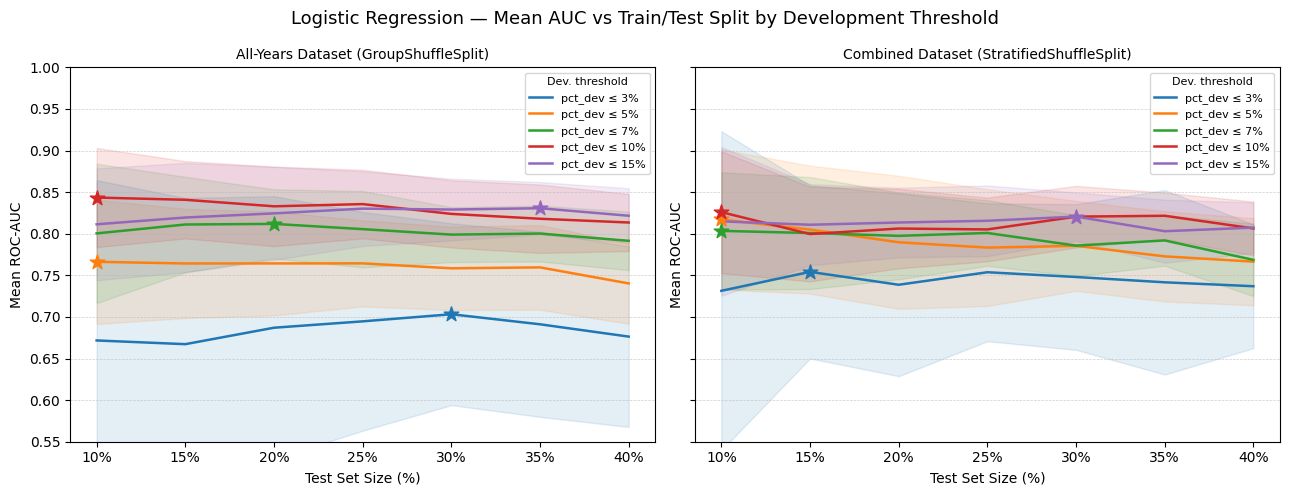

In [47]:
import io, contextlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

test_sizes = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
colors     = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
labels     = ['3%', '5%', '7%', '10%', '15%']

# Re-collect full results quietly (suppress the per-dataset print tables)
all_results  = {}
comb_results = {}

with contextlib.redirect_stdout(io.StringIO()):
    for name, df in datasets:
        r, _ = evaluate_split_ratios(df, name)
        all_results[name] = r
    for name, df in combined_datasets:
        r, _ = evaluate_split_ratios_combined(df, name)
        comb_results[name] = r

x = [ts * 100 for ts in test_sizes]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle('Logistic Regression — Mean AUC vs Train/Test Split by Development Threshold', fontsize=13)

for ax, result_dict, title in [
    (axes[0], all_results,  'All-Years Dataset (GroupShuffleSplit)'),
    (axes[1], comb_results, 'Combined Dataset (StratifiedShuffleSplit)'),
]:
    for (name, res), color, label in zip(result_dict.items(), colors, labels):
        means = [res[ts]['mean_auc'] for ts in test_sizes]
        stds  = [res[ts]['std_auc']  for ts in test_sizes]
        best  = max(test_sizes, key=lambda ts: res[ts]['mean_auc'])

        ax.plot(x, means, color=color, linewidth=1.8, label=f'pct_dev ≤ {label}')
        ax.fill_between(
            x,
            [m - s for m, s in zip(means, stds)],
            [m + s for m, s in zip(means, stds)],
            color=color, alpha=0.12,
        )
        ax.scatter(
            [best * 100], [res[best]['mean_auc']],
            color=color, marker='*', s=120, zorder=5,
        )

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Test Set Size (%)')
    ax.set_ylabel('Mean ROC-AUC')
    ax.set_xticks(x)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.set_ylim(0.55, 1.0)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.legend(fontsize=8, title='Dev. threshold', title_fontsize=8)
    ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()

In [1]:
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
import matplotlib.pyplot as plt
import os

# ── FLAGS ─────────────────────────────────────────────────────────────────────
THRESHOLD = 3      # choose from: 3, 5, 7, 10, 15
TEST_SIZE  = 0.30   # e.g. 0.10, 0.15, 0.20, 0.25, 0.30
# ─────────────────────────────────────────────────────────────────────────────

threshold_map = {3: all_3, 5: all_5, 7: all_7, 10: all_10, 15: all_15}
assert THRESHOLD in threshold_map, f"THRESHOLD must be one of {list(threshold_map)}"
df = threshold_map[THRESHOLD]

feature_cols = df.columns.difference(['Unique_ID', 'cw_ind', 'pct_dev']).tolist()
X      = df[feature_cols].values
y      = df['cw_ind'].values
groups = df['Unique_ID'].apply(extract_site_id).values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=42)
train_idx, test_idx = next(gss.split(X_scaled, y, groups))

X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]
auc    = roc_auc_score(y_test, y_prob)

print(f"Dataset : all_{THRESHOLD}  (pct_dev <= {THRESHOLD}%)")
print(f"Train   : {len(X_train)} obs ({len(np.unique(groups[train_idx]))} sites)")
print(f"Test    : {len(X_test)} obs ({len(np.unique(groups[test_idx]))} sites)")
print(f"\nROC-AUC : {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['absent (0)', 'present (1)']))

# --- Confusion matrix + ROC curve side by side ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['absent (0)', 'present (1)']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix — all_{THRESHOLD} (LR)')

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=f'LR  AUC={auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_title(f'ROC Curve — all_{THRESHOLD} (LR)')

plt.tight_layout()
plt.show()

# --- Feature coefficients ---
coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': lr.coef_[0],
}).reindex(pd.Series(lr.coef_[0]).abs().sort_values(ascending=False).index)

print("\nFeature coefficients (sorted by |coefficient|):")
print(coef_df.to_string(index=False))

# ── CSV OUTPUTS ───────────────────────────────────────────────────────────────
out_dir = f'./data/lr_train_test_sites/lr_thresh{THRESHOLD}_test{int(TEST_SIZE*100)}'
os.makedirs(out_dir, exist_ok=True)

train_df = df.iloc[train_idx].copy()
train_df.to_csv(f'{out_dir}/train_set.csv', index=False)

test_rows = df.iloc[test_idx].copy()
test_rows = test_rows.assign(y_true=y_test, y_pred=y_pred)

tp = test_rows[(test_rows['y_true'] == 1) & (test_rows['y_pred'] == 1)]
fp = test_rows[(test_rows['y_true'] == 0) & (test_rows['y_pred'] == 1)]
tn = test_rows[(test_rows['y_true'] == 0) & (test_rows['y_pred'] == 0)]
fn = test_rows[(test_rows['y_true'] == 1) & (test_rows['y_pred'] == 0)]

tp.to_csv(f'{out_dir}/test_TP_predicted_present_actual_present.csv', index=False)
fp.to_csv(f'{out_dir}/test_FP_predicted_present_actual_absent.csv',  index=False)
tn.to_csv(f'{out_dir}/test_TN_predicted_absent_actual_absent.csv',   index=False)
fn.to_csv(f'{out_dir}/test_FN_predicted_absent_actual_present.csv',  index=False)

print(f"\nCSVs written to {out_dir}/")
print(f"  train_set.csv                              ({len(train_df)} rows)")
print(f"  test_TP_predicted_present_actual_present   ({len(tp)} rows)")
print(f"  test_FP_predicted_present_actual_absent    ({len(fp)} rows)")
print(f"  test_TN_predicted_absent_actual_absent     ({len(tn)} rows)")
print(f"  test_FN_predicted_absent_actual_present    ({len(fn)} rows)")


NameError: name 'all_3' is not defined